In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("D:\git\python-data-analysis-lab\datasets\Real_estates.csv")
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB


In [4]:
df.isna().sum()

Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64

In [5]:
df.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


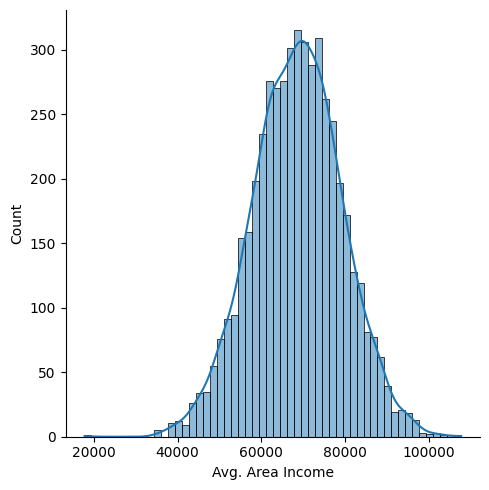

In [6]:
sns.displot(df['Avg. Area Income'], kde=True)
plt.show()

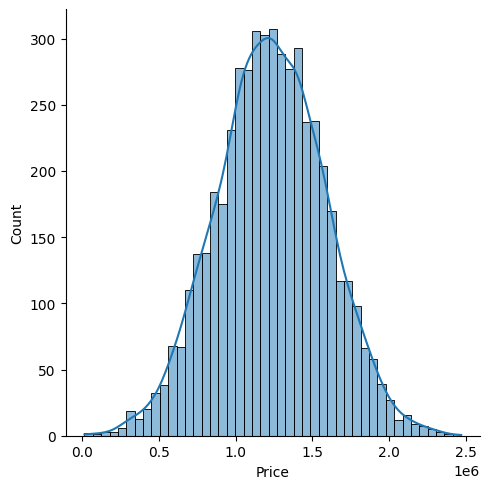

In [7]:
sns.displot(df['Price'], kde =True)
plt.show()

In [9]:
x = df.iloc[:,:-2]
x

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population
0,79545.458574,5.682861,7.009188,4.09,23086.800503
1,79248.642455,6.002900,6.730821,3.09,40173.072174
2,61287.067179,5.865890,8.512727,5.13,36882.159400
3,63345.240046,7.188236,5.586729,3.26,34310.242831
4,59982.197226,5.040555,7.839388,4.23,26354.109472
...,...,...,...,...,...
4995,60567.944140,7.830362,6.137356,3.46,22837.361035
4996,78491.275435,6.999135,6.576763,4.02,25616.115489
4997,63390.686886,7.250591,4.805081,2.13,33266.145490
4998,68001.331235,5.534388,7.130144,5.44,42625.620156


In [10]:
y=df[['Price']]
y

,Price
0,1.059034e+06
1,1.505891e+06
2,1.058988e+06
3,1.260617e+06
4,6.309435e+05
...,...
4995,1.060194e+06
4996,1.482618e+06
4997,1.030730e+06
4998,1.198657e+06


In [11]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y, test_size=0.3,random_state=1)

In [12]:
len(xtrain),len(ytrain),len(xtest),len(ytest)

(3500, 3500, 1500, 1500)

In [13]:
linreg =LinearRegression()

In [14]:
linreg.fit(xtrain,ytrain)

LinearRegression()

In [16]:
ypred = linreg.predict(xtest)
ypred

array([[1555151.93144932],
       [1583399.08583384],
       [ 941481.35482437],
       ...,
       [1099846.27252117],
       [ 974837.76044488],
       [1731306.80613867]])

In [17]:
ytest

,Price
2764,1.413580e+06
4767,1.618721e+06
3814,8.413925e+05
3499,8.814439e+05
2735,1.174748e+06
...,...
4140,9.391390e+05
3969,7.181870e+05
2535,1.109640e+06
1361,1.102641e+06


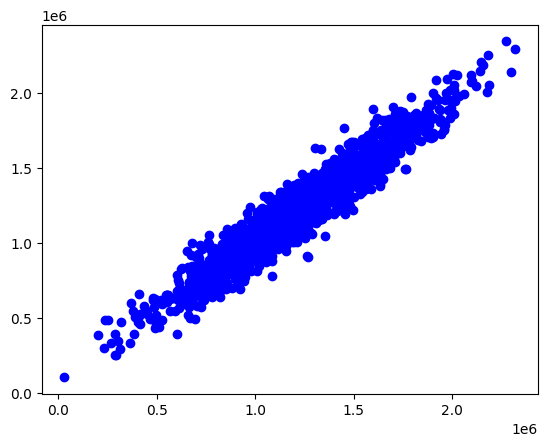

In [18]:
plt.scatter(ytest, ypred, color="blue")
plt.show()

In [19]:
xpred = linreg.predict(xtrain)
xpred

array([[ 829686.51467041],
       [1199036.42183218],
       [ 845641.320423  ],
       ...,
       [1349325.56269213],
       [1234355.26117587],
       [ 930702.60473803]])

In [20]:
ytrain

,Price
1334,9.861132e+05
4768,1.228532e+06
65,8.586856e+05
177,8.942920e+05
4489,1.558572e+06
...,...
2895,1.063206e+06
2763,8.732420e+05
905,1.345963e+06
3980,1.270928e+06


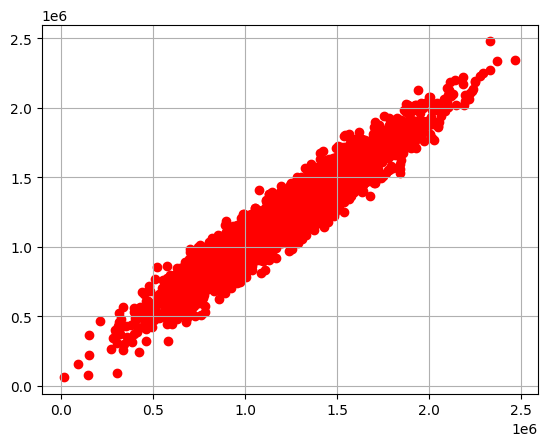

In [22]:
plt.scatter(ytrain, xpred, color="red")
plt.grid()
plt.show()

In [23]:
mse = mean_squared_error(ytest,ypred)
print(f"mse :{mse}")
r2 = r2_score(ytest,ypred)
print(f"r2 : {r2}")

mse :10567448570.9301
r2 : 0.9166912271539811
